<a href="https://colab.research.google.com/github/NelvaAdalit/Machine-Learning-SIS420-Datasets/blob/main/02MIMIC_III_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Dataset 02: MIMIC-III (Demo)

## 📋 Descripción del Dataset
El dataset **MIMIC-III** (Medical Information Mart for Intensive Care) es una base de datos pública a gran escala que contiene información clínica desidentificada de pacientes ingresados en unidades de cuidados intensivos (UCI).
* **Objetivo:** Predecir la mortalidad hospitalaria del paciente (`HOSPITAL_EXPIRE_FLAG`) mediante clasificación binaria (1 = Falleció, 0 = Sobrevivió).
* **Tablas principales utilizadas:** `ADMISSIONS.csv` y `PATIENTS.csv`.

## 🛠️ Archivos en esta carpeta
* `mimic-iii-clinical-database-demo-1.4.zip`: Archivo original comprimido que contiene las múltiples tablas clínicas.
* `02_MIMIC_III_Analysis.ipynb`: Cuaderno de Google Colab con el código de extracción, preprocesamiento y análisis.

## ⚙️ Trabajo y Preparación de Datos (Preprocesamiento)
Para preparar este dataset relacional complejo y dejarlo listo para modelos de clasificación (como Regresión Logística o Redes Neuronales en PyTorch), se ejecutaron los siguientes pasos:

1. **Extracción en Memoria:** Se utilizó el comando `!unzip` en Colab para extraer los datos de forma eficiente en la memoria temporal.
2. **Fusión de Datos (Merge):** Se unieron las tablas `ADMISSIONS` y `PATIENTS` utilizando el identificador único `SUBJECT_ID` para consolidar el historial y demografía del paciente.
3. **Selección de Características (Feature Selection):** Se descartaron fechas e identificadores, conservando únicamente variables predictivas clave (`GENDER`, `ADMISSION_TYPE`, `INSURANCE`, `RELIGION`, `MARITAL_STATUS`, `ETHNICITY`, `DIAGNOSIS`).
4. **Tratamiento de Nulos (NaN):**
   * Variables de texto vacías tratadas con la **Moda**.
   * Variables numéricas vacías tratadas con la **Media**.
5. **Codificación Categórica (Label Encoding):** Se transformó el texto médico (Ej. "EMERGENCY" o "MALE") a identificadores numéricos mediante `LabelEncoder`.
6. **Normalización Z-Score:** Aislamiento de la variable objetivo (`y`) y normalización manual `(X - mu) / sigma` de las variables predictoras (`X`).

## 📊 Resultados Exploratorios
El análisis exploratorio incluye una gráfica que cruza el **Tipo de Ingreso** con la **Mortalidad Hospitalaria**. Esto permite visualizar tendencias (por ejemplo, si los ingresos por urgencias presentan una tasa de mortalidad estadísticamente diferente a los ingresos programados).

---
*Preparación realizada para la Primera Parte del Examen Parcial.*

# Análisis del Dataset MIMIC-III
Este cuaderno realiza un análisis del dataset MIMIC-III, incluyendo descompresión, carga de datos, tratamiento de valores nulos, codificación de variables categóricas, normalización y visualización exploratoria.

## 1. Conexión y Librerías
Conexión con Google Drive e importación de librerías necesarias.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
print("Librerías cargadas correctamente.")

Mounted at /content/gdrive
Librerías cargadas correctamente.


## 2. Descompresión y Carga de Datos
Descompresión del archivo ZIP y carga de las tablas principales.

In [2]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

# Ruta del archivo ZIP en Google Drive
ruta_zip = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/02_MIMIC_III/mimic-iii-clinical-database-demo-1.4.zip'

# Crear un directorio permanente en Google Drive para los datos descomprimidos
ruta_datos_descomprimidos = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/02_MIMIC_III/mimic-data'
!mkdir -p "{ruta_datos_descomprimidos}"

# Descomprimir el archivo ZIP en el directorio permanente
!unzip -o "{ruta_zip}" -d "{ruta_datos_descomprimidos}"

# Actualizar las rutas de los archivos CSV para que apunten a la ubicación descomprimida
ruta_admissions = f'{ruta_datos_descomprimidos}/mimic-iii-clinical-database-demo-1.4/ADMISSIONS.csv'
ruta_patients = f'{ruta_datos_descomprimidos}/mimic-iii-clinical-database-demo-1.4/PATIENTS.csv'

# Cargar los datos
df_admissions = pd.read_csv(ruta_admissions)
df_patients = pd.read_csv(ruta_patients)

# Convertir nombres de columnas a minúsculas
df_admissions.columns = df_admissions.columns.str.lower()
df_patients.columns = df_patients.columns.str.lower()

# Unir las dos tablas usando el ID del paciente (en minúsculas)
if 'subject_id' in df_admissions.columns and 'subject_id' in df_patients.columns:
    df_master = pd.merge(df_admissions, df_patients, on='subject_id', how='inner')
    print("Merge realizado correctamente.")
else:
    print("Error: La columna 'subject_id' no está presente en ambos DataFrames.")

# Seleccionar las características en minúsculas
columnas_utiles = ['gender', 'admission_type', 'insurance', 'religion',
                   'marital_status', 'ethnicity', 'diagnosis', 'hospital_expire_flag']

df = df_master[columnas_utiles].copy()

print("="*70)
print(f"DATASET MAESTRO CREADO: {df.shape[0]} filas y {df.shape[1]} columnas")
print("="*70)
display(df.head(3))

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Archive:  /content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/02_MIMIC_III/mimic-iii-clinical-database-demo-1.4.zip
  inflating: /content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/02_MIMIC_III/mimic-data/mimic-iii-clinical-database-demo-1.4/ADMISSIONS.csv  
  inflating: /content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/02_MIMIC_III/mimic-data/mimic-iii-clinical-database-demo-1.4/CALLOUT.csv  
  inflating: /content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/02_MIMIC_III/mimic-data/mimic-iii-clinical-database-demo-1.4/CAREGIVERS.csv  
  inflating: /content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/02_MIMIC_III/mimic-data/mimic-iii-clinical-database-demo-1.4/CHARTEVENTS.csv  
  inflating: /content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/02_MIMIC_III/mimic-data/mimic-iii-clinical-database-demo-1.4/CPTEVENTS.csv  
  inflating

,gender,admission_type,insurance,religion,marital_status,ethnicity,diagnosis,hospital_expire_flag
0,F,EMERGENCY,Medicare,CATHOLIC,SEPARATED,BLACK/AFRICAN AMERICAN,SEPSIS,0
1,F,EMERGENCY,Private,CATHOLIC,SINGLE,UNKNOWN/NOT SPECIFIED,HEPATITIS B,1
2,F,EMERGENCY,Medicare,CATHOLIC,NaN,UNKNOWN/NOT SPECIFIED,SEPSIS,1


### 3. Tratamiento de Valores Nulos (Antes y Después)
Se identifican las columnas que tienen datos faltantes (`NaN`).
- A las variables de texto (categóricas) se les imputa la **Moda** (el valor más frecuente).
- A las numéricas se les imputa la **Media**.
Se imprime el estado del dataset antes y después de la limpieza.

## 3. Tratamiento de Valores Nulos
Identificación y tratamiento de valores nulos.

In [3]:
# ==============================================================================
# 3. ANTES Y DESPUÉS: TRATAMIENTO DE NULOS
# ==============================================================================
print("="*70)
print(" FASE 1: TRATAMIENTO DE VALORES NULOS (VACÍOS)")
print("="*70)

# ANTES
nulos_antes = df.isnull().sum()
columnas_con_nulos = nulos_antes[nulos_antes > 0]
print("\n🔴 [ANTES] Columnas que tienen datos faltantes:")
if not columnas_con_nulos.empty:
    print(columnas_con_nulos.to_string())
else:
    print("Ningún dato faltante detectado inicialmente.")

# PROCESO: Llenar nulos
for columna in df.columns:
    if df[columna].dtype == 'object':
        df[columna] = df[columna].fillna(df[columna].mode()[0]) # Textos -> Moda
    else:
        df[columna] = df[columna].fillna(df[columna].mean())    # Números -> Media

# DESPUÉS
print(f"\n🟢 [DESPUÉS] Total de valores nulos restantes en el dataset: {df.isnull().sum().sum()} ✅")

 FASE 1: TRATAMIENTO DE VALORES NULOS (VACÍOS)

🔴 [ANTES] Columnas que tienen datos faltantes:
religion           1
marital_status    16

🟢 [DESPUÉS] Total de valores nulos restantes en el dataset: 0 ✅


### 4. Codificación de Variables Categóricas (Label Encoding)
Los modelos matemáticos no pueden procesar texto médico como "EMERGENCY" o "CATHOLIC".
Se utiliza `LabelEncoder` de Scikit-Learn para asignar un valor numérico único a cada categoría. A continuación se muestra la tabla comparativa del **Antes (texto)** y **Después (números)**.

### 4. Diccionario de Variables Clínicas y Codificación
Para el análisis de mortalidad en la UCI, se han consolidado las siguientes variables categóricas que serán transformadas a formato numérico:

* **gender**: Género biológico del paciente (Femenino/Masculino).
* **admission_type**: Tipo de ingreso hospitalario (EMERGENCY, ELECTIVE, URGENT).
* **insurance**: Régimen de aseguramiento médico (Medicare, Private, Medicaid, etc.).
* **religion**: Afiliación religiosa del paciente.
* **marital_status**: Estado civil reportado al ingreso.
* **ethnicity**: Origen étnico o raza del paciente.
* **diagnosis**: Diagnóstico clínico inicial por el cual fue ingresado a cuidados intensivos.
* **hospital_expire_flag (Target)**: Variable objetivo donde 1 indica fallecimiento hospitalario y 0 supervivencia.

In [4]:
# ==============================================================================
# 4. ANTES Y DESPUÉS: CODIFICACIÓN DE TODAS LAS VARIABLES CATEGÓRICAS (50 FILAS)
# ==============================================================================
print("="*80)
print(" FASE 2: TRANSFORMACIÓN DE TEXTO MÉDICO A IDENTIFICADORES NUMÉRICOS")
print("="*80)

# Configuramos pandas para visualizar el bloque completo solicitado
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)

# Detectamos automáticamente las columnas que contienen texto (categorías)
columnas_texto = df.select_dtypes(include=['object']).columns.tolist()

# ------------------------------------------------------------------------------
# ANTES: Visualización de las categorías originales (Texto Médico)
# ------------------------------------------------------------------------------
print(f"\n🔴 [ANTES] Se detectaron {len(columnas_texto)} columnas categóricas.")
print("Mostrando las primeras 50 filas para validación del Ingeniero:")
display(df[columnas_texto].head(50))

# PROCESO: Transformación rigurosa con LabelEncoder
encoder = LabelEncoder()
for columna in columnas_texto:
    # Aseguramos formato string antes de codificar para evitar errores de tipo
    df[columna] = encoder.fit_transform(df[columna].astype(str))

# ------------------------------------------------------------------------------
# DESPUÉS: Visualización de la codificación final
# ------------------------------------------------------------------------------
print("\n🟢 [DESPUÉS] Todas las variables clínicas han sido convertidas a números:")
print("La matriz está ahora lista para el procesamiento por el modelo matemático.")
display(df[columnas_texto].head(50))

# Restauramos la configuración de visualización
pd.reset_option('display.max_rows')

 FASE 2: TRANSFORMACIÓN DE TEXTO MÉDICO A IDENTIFICADORES NUMÉRICOS

🔴 [ANTES] Se detectaron 7 columnas categóricas.
Mostrando las primeras 50 filas para validación del Ingeniero:


,gender,admission_type,insurance,religion,marital_status,ethnicity,diagnosis
0,F,EMERGENCY,Medicare,CATHOLIC,SEPARATED,BLACK/AFRICAN AMERICAN,SEPSIS
1,F,EMERGENCY,Private,CATHOLIC,SINGLE,UNKNOWN/NOT SPECIFIED,HEPATITIS B
2,F,EMERGENCY,Medicare,CATHOLIC,MARRIED,UNKNOWN/NOT SPECIFIED,SEPSIS
3,F,EMERGENCY,Medicare,CATHOLIC,DIVORCED,WHITE,HUMERAL FRACTURE
4,M,EMERGENCY,Medicare,CATHOLIC,DIVORCED,WHITE,ALCOHOLIC HEPATITIS
5,F,EMERGENCY,Medicare,OTHER,MARRIED,WHITE,STROKE/TIA
6,F,ELECTIVE,Medicare,CATHOLIC,MARRIED,WHITE,MITRAL REGURGITATION;CORONARY ARTERY DISEASE\...
7,M,EMERGENCY,Medicare,PROTESTANT QUAKER,DIVORCED,WHITE,SYNCOPE;TELEMETRY
8,M,EMERGENCY,Medicare,CATHOLIC,WIDOWED,WHITE,RIGHT HUMEROUS FRACTURE
9,F,EMERGENCY,Medicare,CATHOLIC,MARRIED,WHITE,RENAL FAILIURE-SYNCOPE-HYPERKALEMIA



🟢 [DESPUÉS] Todas las variables clínicas han sido convertidas a números:
La matriz está ahora lista para el procesamiento por el modelo matemático.


,gender,admission_type,insurance,religion,marital_status,ethnicity,diagnosis
0,0,1,2,1,2,2,73
1,0,1,3,1,3,7,36
2,0,1,2,1,1,7,73
3,0,1,2,1,0,8,37
4,1,1,2,1,0,8,8
5,0,1,2,6,1,8,80
6,0,0,2,1,1,8,0
7,1,1,2,7,0,8,82
8,1,1,2,1,5,8,67
9,0,1,2,1,1,8,65


## 5. Normalización
Preparación de datos para modelos sensibles a escalas.

In [5]:
X = df.drop('hospital_expire_flag', axis=1).values
y = df['hospital_expire_flag'].values

def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    return (X - mu) / sigma

X_norm = featureNormalize(X)
print('Datos normalizados.')

Datos normalizados.


## 6. Visualización Exploratoria
Relación entre tipo de ingreso y mortalidad.

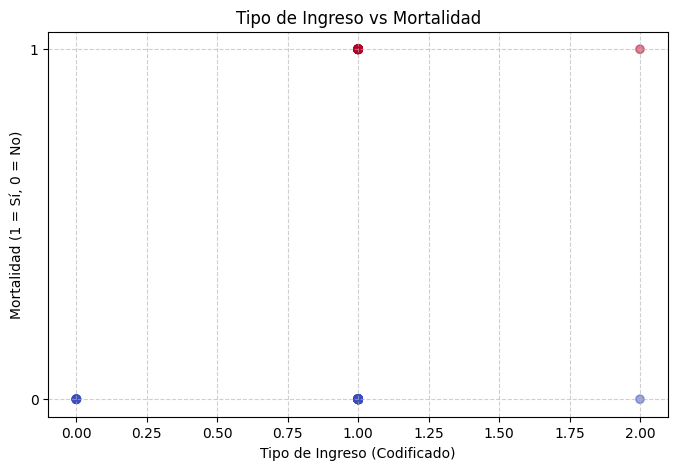

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df['admission_type'], df['hospital_expire_flag'], c=df['hospital_expire_flag'], cmap='coolwarm', alpha=0.5)
plt.title('Tipo de Ingreso vs Mortalidad')
plt.xlabel('Tipo de Ingreso (Codificado)')
plt.ylabel('Mortalidad (1 = Sí, 0 = No)')
plt.yticks([0, 1])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()